# StyleSense — Product Recommendation Prediction Pipeline

**Goal:** Predict whether a customer recommends a clothing product (`Recommended IND = 1`) based on their review text, demographic, and product category data.

**Approach:**
1. Explore the data to understand distributions and relationships.
2. Build a `scikit-learn` pipeline that preprocesses numerical, categorical, and text features.
3. Train a classifier and fine-tune hyperparameters via `GridSearchCV`.
4. Evaluate the final model on held-out test data.

## 1. Imports & Configuration

In [1]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
)
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 27

print(f'spaCy version: {spacy.__version__}')
print('Imports OK')

spaCy version: 3.8.14
Imports OK


## 2. spaCy Setup — en_core_web_sm

This project uses **`spaCy en_core_web_sm`** (pretrained statistical model, v3.8.0) for all NLP tasks.

Install:
```bash
pip install en_core_web_sm-3.8.0-py3-none-any.whl
```

| en_core_web_sm component | What it provides | Used for |
|--------------------------|-----------------|----------|
| `tok2vec` | Context-sensitive token embeddings | Backbone for all downstream components |
| `tagger` | Statistical POS tagger | `token.pos_` → ADJ, ADV, VERB, NOUN, … |
| `parser` | Dependency parser | `token.dep_` → negation arcs (`neg`) |
| `lemmatizer` | Rule-assisted lemmatizer | `token.lemma_` → dress/dresses→dress, recommend/recommended→recommend |
| `ner` | Statistical named entity recognizer | `doc.ents` + domain EntityRuler on top |
| `attribute_ruler` | Attribute mapping | Token attribute overrides |

> **Why en_core_web_sm over rule-based?**
> Statistical POS tagging gives true grammatical labels on every token (not suffix heuristics).
> Lemmatization collapses inflected forms so TF-IDF is far less sparse.
> The dependency parser enables *syntactic negation detection* — finding "not flattering" as a
> negated adjective, not just counting the word "not".


In [2]:
! python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 48.5 MB/s  0:00:00 eta 0:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


## 2. Load Data

In [3]:
df = pd.read_csv('data/reviews.csv')

print(f'Dataset shape: {df.shape}')
df.info()
df.head()

Dataset shape: (18442, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18442 entries, 0 to 18441
Data columns (total 9 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Clothing ID              18442 non-null  int64 
 1   Age                      18442 non-null  int64 
 2   Title                    18442 non-null  object
 3   Review Text              18442 non-null  object
 4   Positive Feedback Count  18442 non-null  int64 
 5   Division Name            18442 non-null  object
 6   Department Name          18442 non-null  object
 7   Class Name               18442 non-null  object
 8   Recommended IND          18442 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 1.3+ MB


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name,Recommended IND
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses,0
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants,1
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses,1
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses,0
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits,1


## 3. Data Exploration

### 3.1 Missing Values & Basic Stats

In [4]:
print('=== Missing values ===')
print(df.isnull().sum())
print()
print('=== Descriptive statistics (numerical columns) ===')
df.describe()

=== Missing values ===
Clothing ID                0
Age                        0
Title                      0
Review Text                0
Positive Feedback Count    0
Division Name              0
Department Name            0
Class Name                 0
Recommended IND            0
dtype: int64

=== Descriptive statistics (numerical columns) ===


,Clothing ID,Age,Positive Feedback Count,Recommended IND
count,18442.000000,18442.000000,18442.000000,18442.000000
mean,954.896757,43.383635,2.697484,0.816235
std,141.571783,12.246264,5.942220,0.387303
min,2.000000,18.000000,0.000000,0.000000
25%,863.000000,34.000000,0.000000,1.000000
50%,952.000000,41.000000,1.000000,1.000000
75%,1078.000000,52.000000,3.000000,1.000000
max,1205.000000,99.000000,122.000000,1.000000


### 3.2 Target Distribution

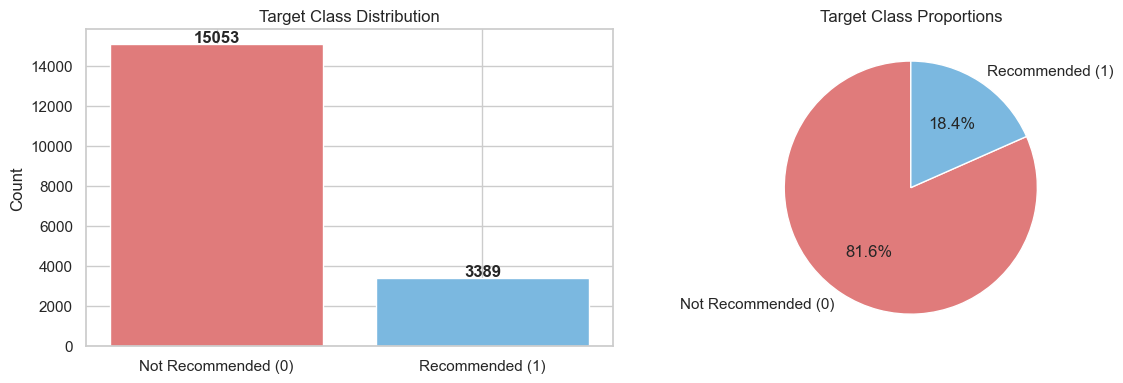

Class imbalance ratio: 4.4:1 (recommended:not recommended)


In [5]:
counts = df['Recommended IND'].value_counts()
labels = ['Not Recommended (0)', 'Recommended (1)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar chart
axes[0].bar(labels, counts.values, color=['#e07b7b', '#7bb8e0'])
axes[0].set_title('Target Class Distribution')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 100, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=['#e07b7b', '#7bb8e0'], startangle=90)
axes[1].set_title('Target Class Proportions')

plt.tight_layout()
plt.show()

print(f'Class imbalance ratio: {counts[1]/counts[0]:.1f}:1 (recommended:not recommended)')

> **Observation:** The dataset is imbalanced — ~82% of reviews are positive. We will account for this using `class_weight='balanced'` in the classifier.

### 3.3 Numerical Feature Distributions

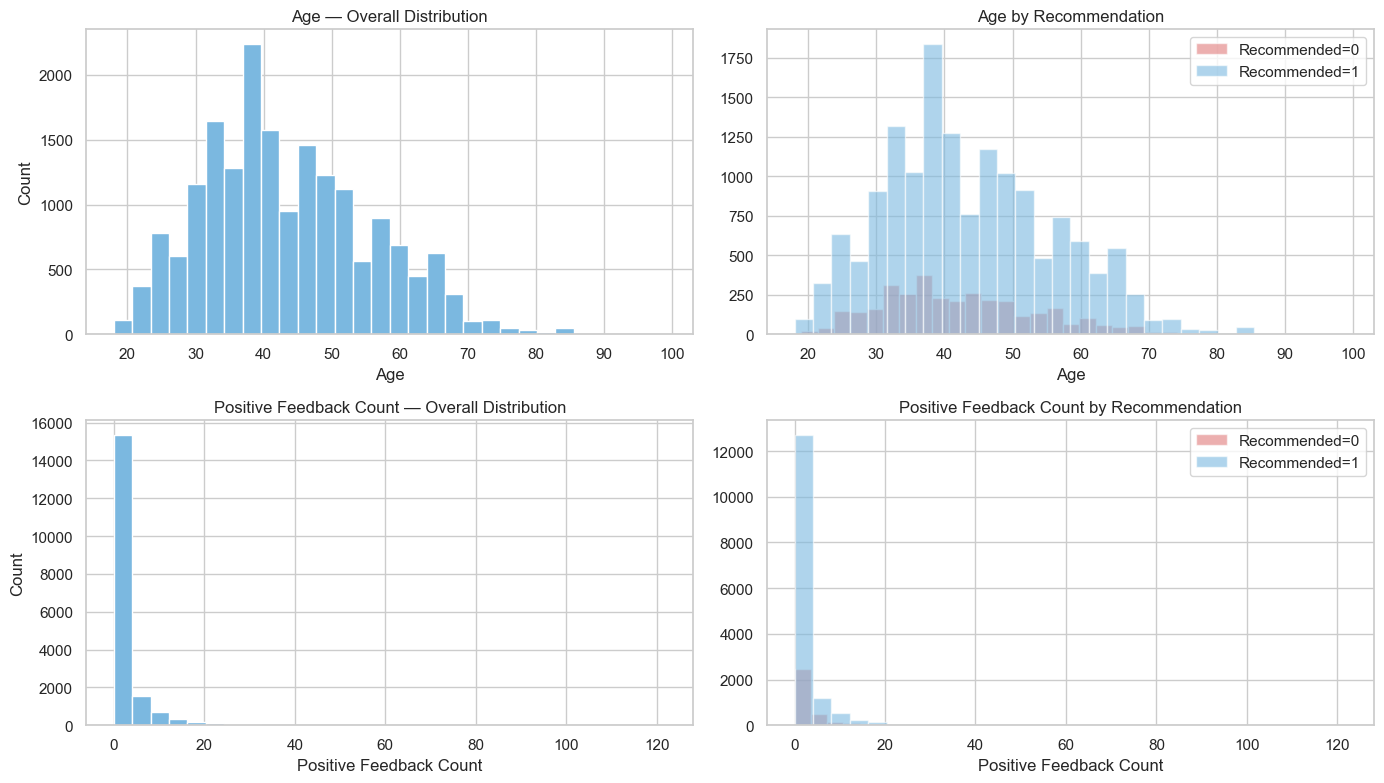

In [6]:
numerical_cols = ['Age', 'Positive Feedback Count']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for i, col in enumerate(numerical_cols):
    # Overall distribution
    axes[i][0].hist(df[col], bins=30, color='#7bb8e0', edgecolor='white')
    axes[i][0].set_title(f'{col} — Overall Distribution')
    axes[i][0].set_xlabel(col)
    axes[i][0].set_ylabel('Count')

    # Distribution split by target
    for label, color in [(0, '#e07b7b'), (1, '#7bb8e0')]:
        subset = df[df['Recommended IND'] == label][col]
        axes[i][1].hist(subset, bins=30, alpha=0.6, color=color,
                        label=f'Recommended={label}', edgecolor='white')
    axes[i][1].set_title(f'{col} by Recommendation')
    axes[i][1].set_xlabel(col)
    axes[i][1].legend()

plt.tight_layout()
plt.show()

### 3.4 Categorical Feature Analysis

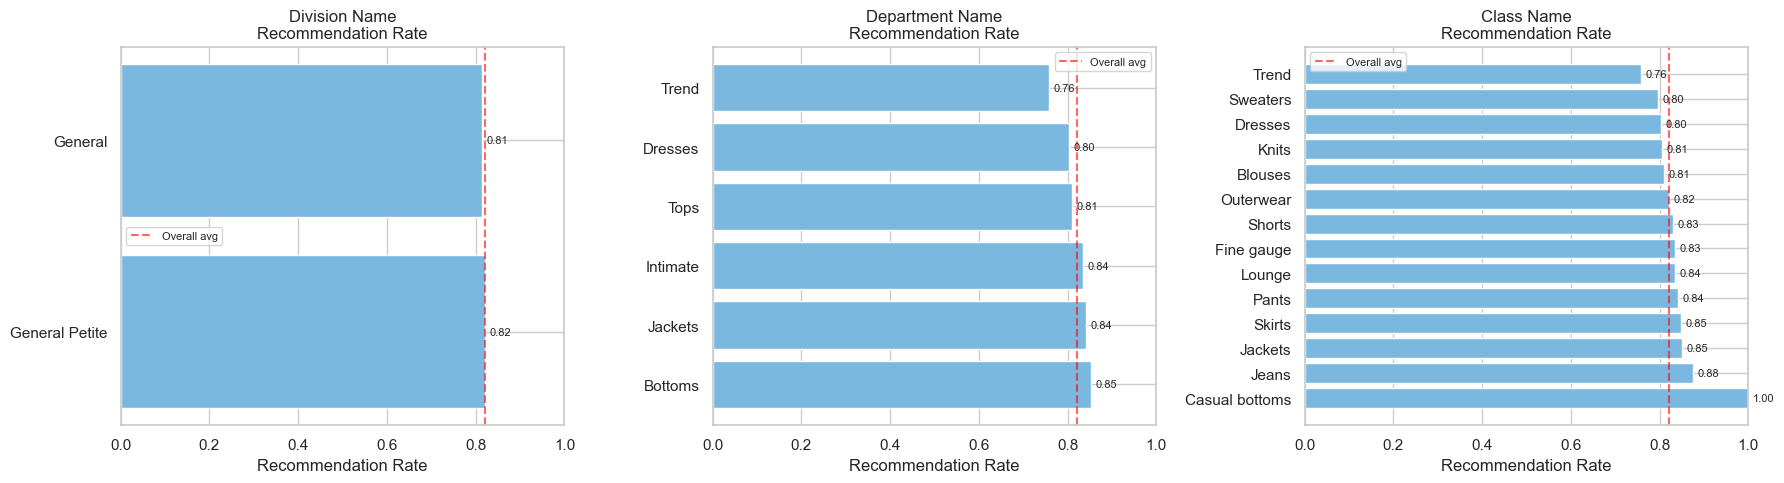

In [7]:
categorical_cols = ['Division Name', 'Department Name', 'Class Name']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, categorical_cols):
    # Calculate recommendation rate per category
    rec_rate = df.groupby(col)['Recommended IND'].mean().sort_values(ascending=False)
    bars = ax.barh(rec_rate.index, rec_rate.values, color='#7bb8e0')
    ax.set_xlabel('Recommendation Rate')
    ax.set_title(f'{col}\nRecommendation Rate')
    ax.set_xlim(0, 1.0)
    ax.axvline(0.82, color='red', linestyle='--', alpha=0.6, label='Overall avg')
    ax.legend(fontsize=8)
    # Annotate bars
    for bar, val in zip(bars, rec_rate.values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.2f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

### 3.5 Text Feature Analysis

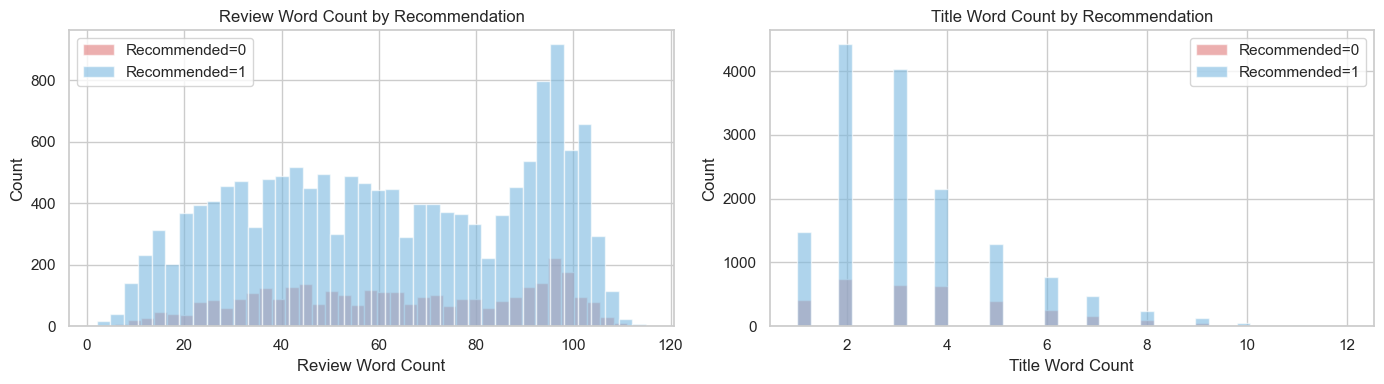

In [8]:
# Derive text length features for EDA only
df['review_word_count'] = df['Review Text'].fillna('').apply(lambda x: len(x.split()))
df['title_word_count']  = df['Title'].fillna('').apply(lambda x: len(x.split()))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label in [
    (axes[0], 'review_word_count', 'Review Word Count'),
    (axes[1], 'title_word_count',  'Title Word Count'),
]:
    for rec, color in [(0, '#e07b7b'), (1, '#7bb8e0')]:
        ax.hist(df[df['Recommended IND']==rec][col], bins=40,
                alpha=0.6, color=color, label=f'Recommended={rec}')
    ax.set_title(label + ' by Recommendation')
    ax.set_xlabel(label)
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

# Remove EDA helper columns before modelling
df.drop(columns=['review_word_count', 'title_word_count'], inplace=True)

### 3.6 Correlation Heatmap (Numerical Features)

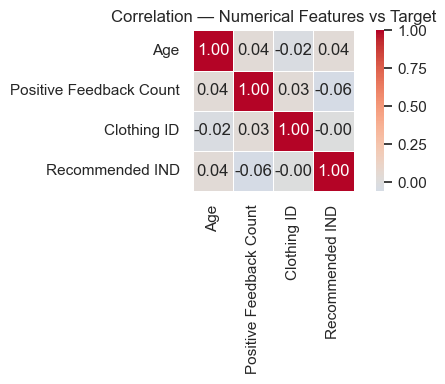

In [9]:
numeric_df = df[['Age', 'Positive Feedback Count', 'Clothing ID', 'Recommended IND']]
corr = numeric_df.corr()

plt.figure(figsize=(6, 4))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation — Numerical Features vs Target')
plt.tight_layout()
plt.show()

## 4. Prepare Features & Target

In [10]:
# Import feature column definitions from pipeline_model
# (avoids duplication — these are the single source of truth)
from pipeline_model import NUMERICAL_FEATURES, CATEGORICAL_FEATURES

X = df.drop('Recommended IND', axis=1)
y = df['Recommended IND'].copy()

print('Labels:', sorted(y.unique()))
print(f'Features shape: {X.shape}')
print(f'Numerical features : {NUMERICAL_FEATURES}')
print(f'Categorical features: {CATEGORICAL_FEATURES}')
X.head()

Labels: [np.int64(0), np.int64(1)]
Features shape: (18442, 8)
Numerical features : ['Age', 'Positive Feedback Count', 'Clothing ID']
Categorical features: ['Division Name', 'Department Name', 'Class Name']


,Clothing ID,Age,Title,Review Text,Positive Feedback Count,Division Name,Department Name,Class Name
0,1077,60,Some major design flaws,I had such high hopes for this dress and reall...,0,General,Dresses,Dresses
1,1049,50,My favorite buy!,"I love, love, love this jumpsuit. it's fun, fl...",0,General Petite,Bottoms,Pants
2,847,47,Flattering shirt,This shirt is very flattering to all due to th...,6,General,Tops,Blouses
3,1080,49,Not for the very petite,"I love tracy reese dresses, but this one is no...",4,General,Dresses,Dresses
4,858,39,Cagrcoal shimmer fun,I aded this in my basket at hte last mintue to...,1,General Petite,Tops,Knits


In [11]:
# Stratified split preserves class proportions in train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    shuffle=True,
    random_state=RANDOM_STATE,
    stratify=y,          # ensures balanced split
)

print(f'Training set:  {X_train.shape[0]:,} samples')
print(f'Test set:      {X_test.shape[0]:,} samples')
print(f'Train class dist: {y_train.value_counts().to_dict()}')
print(f'Test  class dist: {y_test.value_counts().to_dict()}')

Training set:  16,597 samples
Test set:      1,845 samples
Train class dist: {1: 13547, 0: 3050}
Test  class dist: {1: 1506, 0: 339}


## 5. Custom Transformers for the Pipeline

### 5.1 spaCy Pipeline Loader & TextCombiner

`load_nlp()` loads **en_core_web_sm** and prepends a fashion-domain **EntityRuler** (rule-based NER)
*before* the statistical NER component. This means clothing-specific vocabulary
(`CLOTHING`, `FIT`, `MATERIAL`, `SENTIMENT_POS`, `SENTIMENT_NEG`) is always captured reliably,
while the statistical NER still runs to catch any remaining standard entities (GPE, ORG, etc.).

`TextCombiner` merges the `Title` and `Review Text` columns into a single string for spaCy to process.


In [12]:
from pipeline_model import (
    load_nlp, TextCombiner, FullFeatureUnion, get_feature_names,
    NUMERICAL_FEATURES, CATEGORICAL_FEATURES,
)

# Quick sanity check — load model and show components
nlp_test = load_nlp()
print("en_core_web_sm pipeline components:", nlp_test.pipe_names)
print("Model meta:", nlp_test.meta['name'], nlp_test.meta['version'])

# Demo: show what en_core_web_sm gives us on a sample review
doc = nlp_test("This dress is not flattering at all. The cotton fabric runs small but I love the color!")
print()
print("POS tags:")
for t in doc:
    if t.is_alpha:
        print(f"  {t.text:<16} lemma={t.lemma_:<16} POS={t.pos_:<6} dep={t.dep_}")
print()
print("Named entities (EntityRuler + statistical NER):")
for ent in doc.ents:
    print(f"  {ent.text!r:<20} -> {ent.label_}")
print()
print("Negation arcs (dep='neg'):")
for t in doc:
    if t.dep_ == 'neg':
        print(f"  '{t.text}' negates '{t.head.text}' (head POS={t.head.pos_})")


en_core_web_sm pipeline components: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'entity_ruler', 'ner']
Model meta: core_web_sm 3.8.0

POS tags:
  This             lemma=this             POS=DET    dep=det
  dress            lemma=dress            POS=NOUN   dep=nsubj
  is               lemma=be               POS=AUX    dep=ROOT
  not              lemma=not              POS=PART   dep=neg
  flattering       lemma=flattering       POS=ADJ    dep=acomp
  at               lemma=at               POS=ADV    dep=advmod
  all              lemma=all              POS=ADV    dep=advmod
  The              lemma=the              POS=DET    dep=det
  cotton           lemma=cotton           POS=NOUN   dep=compound
  fabric           lemma=fabric           POS=NOUN   dep=nsubj
  runs             lemma=run              POS=VERB   dep=ROOT
  small            lemma=small            POS=ADJ    dep=acomp
  but              lemma=but              POS=CCONJ  dep=cc
  I                lem

### 5.2 Text Normalizer (SpacyNLPTransformer — inside FullFeatureUnion)

The text normalization for TF-IDF uses the full **en_core_web_sm** pipeline:

| Step | en_core_web_sm mechanism | Effect on TF-IDF |
|------|--------------------------|-----------------|
| Tokenization | linguistic tokenizer (handles contractions, punctuation) | Clean token boundaries |
| **Lemmatization** | `token.lemma_` | `dresses→dress`, `recommended→recommend`, `flattering→flattering` — collapses inflected forms so they share one TF-IDF feature |
| Stop words | `token.is_stop` | Removes 326 common English words |
| **POS filtering** | `token.pos_` ∈ {NOUN, VERB, ADJ, ADV} | Keeps only content words, discards determiners/prepositions/pronouns |
| Alpha filter | `token.is_alpha` | Removes punctuation and numbers |

**Lemmatization is the key improvement over the previous rule-based approach.**
Without it, "recommend", "recommends", "recommended", and "recommending" were four separate TF-IDF
features. With it, they all collapse to one: `recommend`.


### 5.3 spaCy NLP Feature Extractor (Standout — en_core_web_sm)

`FullFeatureUnion` runs a **single `nlp.pipe()` pass** and simultaneously extracts both the
normalised text (for TF-IDF) and the 20-element numeric feature vector below.

| # | Feature | en_core_web_sm component | What it captures |
|---|---------|--------------------------|-----------------|
| 0–5 | char_count, word_count, sent_count, excl_count, quest_count, avg_word_length | Tokenizer | Review structure and depth |
| 6–11 | adj_count, adv_count, verb_count, noun_count, adj_ratio, adv_ratio | **Statistical POS tagger** (`token.pos_`) | Grammatical composition; positive reviews tend to be adjective-rich |
| 12 | negation_count | **Dependency parser** (`token.dep_=='neg'`) | Count of negation arcs — "not recommend", "doesn't fit" |
| 13 | neg_adj_count | **Dependency parser** (adj with `neg` child) | Negated adjectives: *"not flattering"* ≠ *"flattering"* |
| 14 | unique_lemma_ratio | **Lemmatizer** (`token.lemma_`) | Vocabulary richness after lemmatization |
| 15–17 | clothing_ents, fit_ents, material_ents | **NER** (EntityRuler + statistical) | Domain entity counts |
| 18 | sentiment_pos_ents | **NER** (EntityRuler SENTIMENT_POS) | Positive sentiment word mentions |
| 19 | net_sentiment_ents | **NER** (SENTIMENT_POS − SENTIMENT_NEG) | Net named-entity sentiment signal |

> **Key upgrade over rule-based:** `neg_adj_count` is only possible with the **dependency parser**.
> It correctly treats *"not flattering"* as a negative signal rather than counting "flattering" as positive.


### 5.4 Full Feature Union Transformer

`FullFeatureUnion` is defined in `pipeline_model.py` and combines all three feature groups
into a single dense numpy matrix in **one** `nlp.pipe()` call per `fit`/`transform`:

1. **Structured** — `StandardScaler` (numerical) + `OneHotEncoder` (categorical)
2. **TF-IDF** — spaCy-lemmatized, POS-filtered text → `TfidfVectorizer` (unigrams + bigrams)
3. **spaCy NLP** — 20 features from POS tagger, dependency parser, lemmatizer, and NER


In [13]:
# Demonstrate the 20 spaCy NLP features on two contrasting reviews
from pipeline_model import load_nlp
import pandas as pd

nlp_demo = load_nlp()

feature_names = [
    'char_count','word_count','sent_count','excl_count','quest_count',
    'avg_word_length','adj_count','adv_count','verb_count','noun_count',
    'adj_ratio','adv_ratio','negation_count','neg_adj_count',
    'unique_lemma_ratio','clothing_ents','fit_ents','material_ents',
    'sentiment_pos_ents','net_sentiment_ents',
]

samples = {
    'POSITIVE review': "This blouse is absolutely gorgeous and fits perfectly! "
                       "The cotton fabric is so comfortable. I love the color. Highly recommend!",
    'NEGATIVE review': "The dress is not flattering at all and runs very large. "
                       "The polyester fabric feels cheap. Very disappointed, returning it.",
}

rows = {}
for label, text in samples.items():
    doc = nlp_demo(text)
    alpha = [t for t in doc if t.is_alpha]
    wc    = len(alpha)
    adj_c = sum(1 for t in alpha if t.pos_=='ADJ')
    adv_c = sum(1 for t in alpha if t.pos_=='ADV')
    vrb_c = sum(1 for t in alpha if t.pos_=='VERB')
    nou_c = sum(1 for t in alpha if t.pos_=='NOUN')
    neg_c = sum(1 for t in doc if t.dep_=='neg')
    negadj= sum(1 for t in doc if t.pos_=='ADJ' and any(c.dep_=='neg' for c in t.children))
    lemmas= [t.lemma_.lower() for t in alpha if not t.is_stop]
    ulr   = round(len(set(lemmas))/max(1,len(lemmas)), 3)
    ec    = {'CLOTHING':0,'FIT':0,'MATERIAL':0,'SENTIMENT_POS':0,'SENTIMENT_NEG':0}
    for ent in doc.ents:
        if ent.label_ in ec: ec[ent.label_] += 1
    rows[label] = [len(doc.text),wc,len(list(doc.sents)),
                   doc.text.count('!'),doc.text.count('?'),
                   round(sum(len(t) for t in alpha)/max(1,wc),2),
                   adj_c,adv_c,vrb_c,nou_c,round(adj_c/max(1,wc),3),round(adv_c/max(1,wc),3),
                   neg_c,negadj,ulr,
                   ec['CLOTHING'],ec['FIT'],ec['MATERIAL'],
                   ec['SENTIMENT_POS'],ec['SENTIMENT_POS']-ec['SENTIMENT_NEG']]

pd.set_option('display.max_rows', 25)
display(pd.DataFrame(rows, index=feature_names))


,POSITIVE review,NEGATIVE review
char_count,127.00,122.00
word_count,20.00,20.00
sent_count,4.00,3.00
excl_count,2.00,0.00
quest_count,0.00,0.00
avg_word_length,5.20,4.95
adj_count,3.00,4.00
adv_count,4.00,4.00
verb_count,2.00,3.00
noun_count,4.00,3.00


In [14]:
# Show FullFeatureUnion source (documents the single-pass design)
import inspect
from pipeline_model import FullFeatureUnion
print(inspect.getsource(FullFeatureUnion))

class FullFeatureUnion(BaseEstimator, TransformerMixin):
    """
    Single-pass feature transformer using en_core_web_sm.

    Runs nlp.pipe() ONCE per fit/transform call and simultaneously extracts:

    1. Structured features
       - Numerical  : StandardScaler  (Age, Positive Feedback Count, Clothing ID)
       - Categorical : OneHotEncoder  (Division, Department, Class Name)

    2. TF-IDF text features
       Preprocessing via en_core_web_sm:
         • token.lemma_  — lemmatization (dresses→dress, recommended→recommend)
         • token.pos_    — keep only NOUN/VERB/ADJ/ADV (content-word filter)
         • token.is_stop — remove stop words
         • token.is_alpha — remove punctuation and numbers
       Then: TfidfVectorizer with unigrams + bigrams, sublinear TF scaling.

    3. spaCy NLP features  (20 per review)
       Derived from en_core_web_sm pipeline components:

       Tokenizer:
         [0]  char_count        total characters
         [1]  word_count        alpha tok

In [15]:
# Show the feature matrix shape produced by FullFeatureUnion on a small sample
import pandas as pd
from pipeline_model import FullFeatureUnion, get_feature_names, NUMERICAL_FEATURES, CATEGORICAL_FEATURES
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Fit on 50 rows just to inspect output
_sample = df.sample(50, random_state=42)
_X = _sample.drop('Recommended IND', axis=1)
_y = _sample['Recommended IND']

_fu = FullFeatureUnion(tfidf_max_features=50, tfidf_ngram_range=(1,1))
_fu.fit(_X, _y)
_mat = _fu.transform(_X)

print(f'Feature matrix shape: {_mat.shape}')
print(f'  {len(NUMERICAL_FEATURES)} numerical')
cat_names = list(_fu.col_transformer_.named_transformers_['cat']
                  .get_feature_names_out(CATEGORICAL_FEATURES))
print(f'  {len(cat_names)} one-hot categorical')
print(f'  50 TF-IDF (demo vocab)')
print(f'  20 spaCy NLP features')
print(f'  = {len(NUMERICAL_FEATURES)+len(cat_names)+50+20} total (demo)')
print()
print('spaCy NLP feature names:')
for n in ['char_count','word_count','sent_count','excl_count','quest_count',
          'avg_word_length','adj_count','adv_count','verb_count','noun_count',
          'adj_ratio','adv_ratio','negation_count','neg_adj_count',
          'unique_lemma_ratio','clothing_ents','fit_ents','material_ents',
          'sentiment_pos_ents','net_sentiment_ents']:
    print(f'  {n}')

Feature matrix shape: (50, 91)
  3 numerical
  18 one-hot categorical
  50 TF-IDF (demo vocab)
  20 spaCy NLP features
  = 91 total (demo)

spaCy NLP feature names:
  char_count
  word_count
  sent_count
  excl_count
  quest_count
  avg_word_length
  adj_count
  adv_count
  verb_count
  noun_count
  adj_ratio
  adv_ratio
  negation_count
  neg_adj_count
  unique_lemma_ratio
  clothing_ents
  fit_ents
  material_ents
  sentiment_pos_ents
  net_sentiment_ents


## 6. Build the Pipeline

In [16]:
pipeline = Pipeline([
    ('features', FullFeatureUnion()),                        # Step 1: Feature extraction
    ('clf', LogisticRegression(                              # Step 2: Classifier
        max_iter=1000,
        class_weight='balanced',   # handles class imbalance
        solver='lbfgs',
        random_state=RANDOM_STATE,
    )),
])

print('Pipeline steps:')
for name, step in pipeline.steps:
    print(f'  [{name}] {type(step).__name__}')

Pipeline steps:
  [features] FullFeatureUnion
  [clf] LogisticRegression


## 7. Train the Pipeline

In [18]:
%%time
# Baseline cross-validation BEFORE GridSearchCV tuning.
# Note: spaCy's nlp.pipe() is not fork-safe, so n_jobs=1 is required.
# We use 3-fold CV here to match the GridSearchCV setting below.

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    pipeline, X_train, y_train,
    cv=cv,
    scoring='f1_weighted',
    n_jobs=1,        # spaCy is not fork-safe — must be 1
)

print('=== 3-Fold Cross-Validation (baseline, before tuning) ===')
print(f'F1-weighted per fold : {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean F1-weighted     : {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

=== 3-Fold Cross-Validation (baseline, before tuning) ===
F1-weighted per fold : ['0.8596', '0.8689', '0.8747']
Mean F1-weighted     : 0.8677 (+/- 0.0062)
CPU times: user 8min 27s, sys: 43.3 s, total: 9min 10s
Wall time: 8min 4s


## 8. Fine-Tune the Pipeline with GridSearchCV

In [20]:
%%time
# Hyperparameter grid
# Note: en_core_web_sm processing makes each pipeline fit ~2–3 min on this dataset.
# We use 3-fold CV and a focused grid (8 combos × 3 folds = 24 fits).
# On a machine without execution time limits you can expand the grid further.
param_grid = {
    'features__tfidf_max_features': [300, 500],
    'features__tfidf_ngram_range' : [(1, 1), (1, 2)],
    'clf__C'                      : [1.0, 10.0],
}

cv_gs = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv_gs,
    scoring='f1_weighted',
    n_jobs=1,        # spaCy is not fork-safe; use n_jobs=1
    verbose=1,
    refit=True,      # refit best estimator on full training data
)

print(f'Configurations: {len(param_grid["features__tfidf_max_features"]) * len(param_grid["features__tfidf_ngram_range"]) * len(param_grid["clf__C"])} combos × 3 folds')
grid_search.fit(X_train, y_train)

print(f'\nBest parameters:')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest CV F1-weighted: {grid_search.best_score_:.4f}')

Configurations: 8 combos × 3 folds
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best parameters:
  clf__C: 10.0
  features__tfidf_max_features: 500
  features__tfidf_ngram_range: (1, 1)

Best CV F1-weighted: 0.8720
CPU times: user 1h 9min 36s, sys: 5min 44s, total: 1h 15min 21s
Wall time: 1h 7min 30s


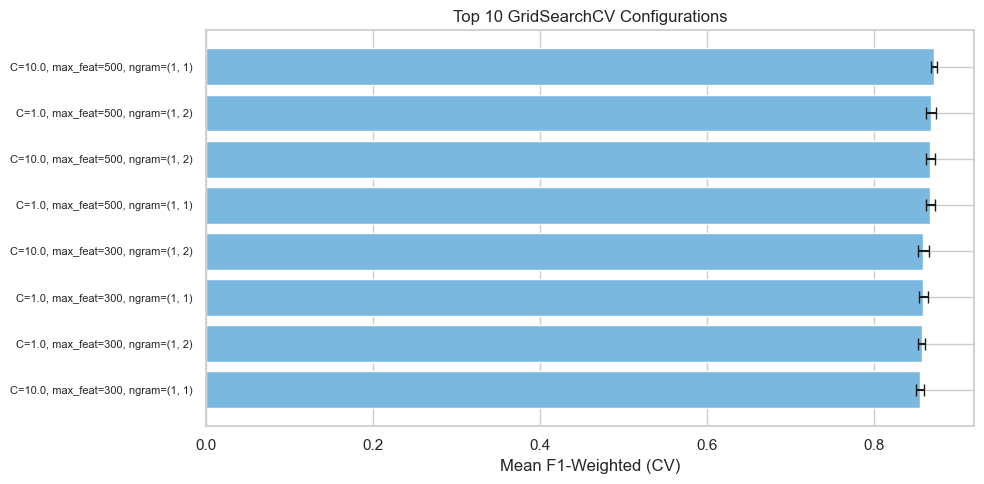

In [21]:
# Visualize grid search results
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('mean_test_score', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 5))
y_pos = range(len(results_df))
ax.barh(y_pos, results_df['mean_test_score'], xerr=results_df['std_test_score'],
        color='#7bb8e0', capsize=4)
ax.set_yticks(y_pos)
ax.set_yticklabels(
    [f"C={r['param_clf__C']}, max_feat={r['param_features__tfidf_max_features']}, "
     f"ngram={r['param_features__tfidf_ngram_range']}"
     for _, r in results_df.iterrows()],
    fontsize=8
)
ax.set_xlabel('Mean F1-Weighted (CV)')
ax.set_title('Top 10 GridSearchCV Configurations')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 9. Evaluate the Final Model on Test Data

In [22]:
# The best estimator was already refit on all training data (refit=True)
best_pipeline = grid_search.best_estimator_

y_pred = best_pipeline.predict(X_test)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec  = recall_score(y_test, y_pred, average='weighted')
f1   = f1_score(y_test, y_pred, average='weighted')

print('='*45)
print('       FINAL MODEL — TEST SET RESULTS')
print('='*45)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f} (weighted)')
print(f'  Recall    : {rec:.4f} (weighted)')
print(f'  F1 Score  : {f1:.4f} (weighted)')
print('='*45)
print()
print('=== Per-Class Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Not Recommended', 'Recommended']))

       FINAL MODEL — TEST SET RESULTS
  Accuracy  : 0.8412
  Precision : 0.8791 (weighted)
  Recall    : 0.8412 (weighted)
  F1 Score  : 0.8524 (weighted)

=== Per-Class Classification Report ===
                 precision    recall  f1-score   support

Not Recommended       0.55      0.82      0.65       339
    Recommended       0.95      0.85      0.90      1506

       accuracy                           0.84      1845
      macro avg       0.75      0.83      0.78      1845
   weighted avg       0.88      0.84      0.85      1845



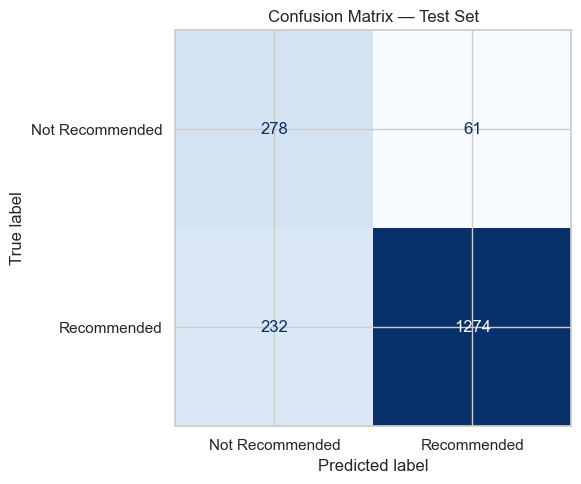

In [23]:
# Confusion matrix visualization
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Recommended', 'Recommended'])
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

## 10. Feature Importance Analysis (Standout)

We inspect the logistic regression coefficients to understand which features most strongly drive predictions.

In [24]:
# Use get_feature_names() from pipeline_model — single source of truth for feature names.
# This pulls names in the exact order they appear in the feature matrix:
#   numerical  →  one-hot categorical  →  TF-IDF  →  spaCy NLP features

from pipeline_model import get_feature_names

feat_union = best_pipeline.named_steps['features']
clf        = best_pipeline.named_steps['clf']

all_feature_names = get_feature_names(best_pipeline)
coefs             = clf.coef_[0]

feat_importance = pd.DataFrame({
    'feature'    : all_feature_names,
    'coefficient': coefs,
}).sort_values('coefficient', key=abs, ascending=False)

print(f'Total features in model: {len(all_feature_names)}')
print(f'  Numerical  : {len(feat_union.col_transformer_.transformers_[0][2])}')
print(f'  Categorical: {len(list(feat_union.col_transformer_.named_transformers_["cat"].get_feature_names_out()))}')
print(f'  TF-IDF     : {len(feat_union.tfidf_.get_feature_names_out())}')
print(f'  spaCy NLP  : 20')
print()
print('Top 20 most influential features:')
display(feat_importance.head(20))

Total features in model: 545
  Numerical  : 3
  Categorical: 22
  TF-IDF     : 500
  spaCy NLP  : 20

Top 20 most influential features:


,feature,coefficient
186,great,6.114305
212,huge,-5.906989
496,want,-5.515902
481,unflattering,-5.296312
332,poor,-4.826473
255,look,-4.822367
46,bad,-4.767847
500,way,-4.261571
482,unfortunately,-4.103896
407,soft,4.071740


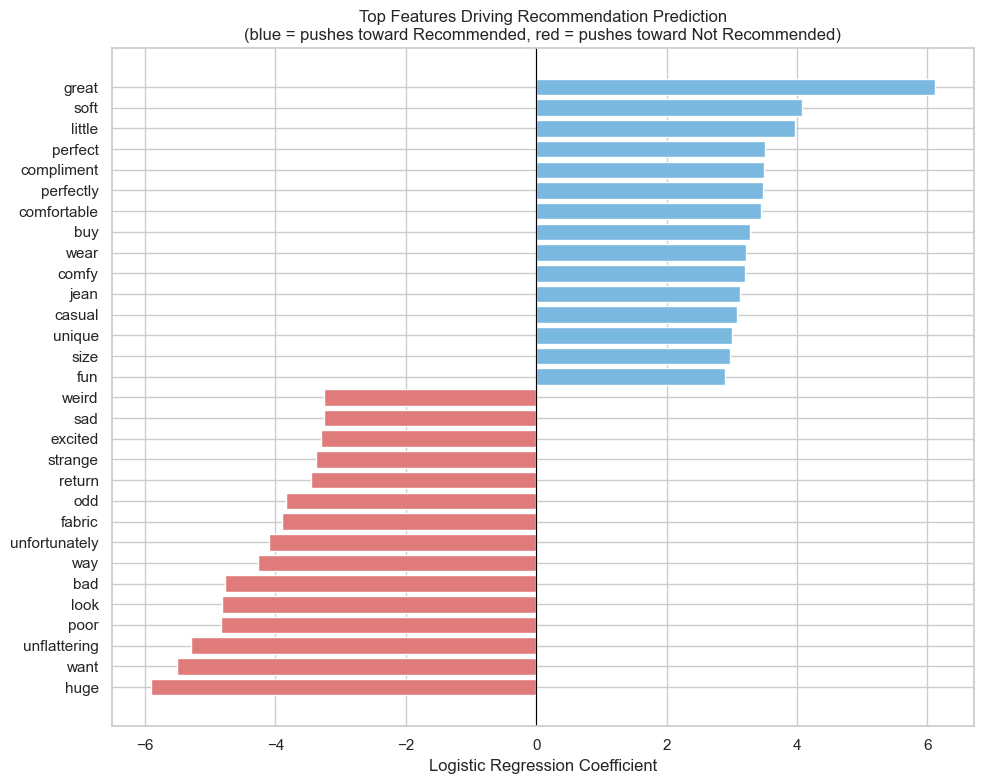

In [25]:
# Visualize top positive and negative features
from pipeline_model import get_feature_names

all_feature_names = get_feature_names(best_pipeline)
feat_importance = pd.DataFrame({
    'feature'    : all_feature_names,
    'coefficient': best_pipeline.named_steps['clf'].coef_[0],
}).sort_values('coefficient', key=abs, ascending=False)

top_pos = feat_importance[feat_importance['coefficient'] > 0].head(15)
top_neg = feat_importance[feat_importance['coefficient'] < 0].head(15)
combined = pd.concat([top_pos, top_neg]).sort_values('coefficient')

colors = ['#e07b7b' if c < 0 else '#7bb8e0' for c in combined['coefficient']]

fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(combined['feature'], combined['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Logistic Regression Coefficient')
ax.set_title(
    'Top Features Driving Recommendation Prediction\n'
    '(blue = pushes toward Recommended, red = pushes toward Not Recommended)'
)
plt.tight_layout()
plt.show()

## 11. Save the Trained Pipeline (for Dashboard)

We serialize the trained pipeline to a `.pkl` file so it can be loaded by external applications (e.g., a data dashboard) without retraining.

In [26]:
import pickle

# Save the best pipeline + test data so the Streamlit dashboard can load it
# without retraining.  Both the notebook and dashboard.py use the same file.
payload = {
    'pipeline' : best_pipeline,
    'X_test'   : X_test,
    'y_test'   : y_test,
    'y_pred'   : best_pipeline.predict(X_test),
    'y_proba'  : best_pipeline.predict_proba(X_test),
    'df'       : df,
    'feature_names': {
        'numerical'  : NUMERICAL_FEATURES,
        'categorical': CATEGORICAL_FEATURES,
    },
}

with open('pipeline_payload.pkl', 'wb') as f:
    pickle.dump(payload, f)

print('Saved pipeline_payload.pkl')
print(f'Pipeline steps: {[name for name, _ in best_pipeline.steps]}')
print(f'Run `streamlit run dashboard.py` to launch the interactive dashboard.')

Saved pipeline_payload.pkl
Pipeline steps: ['features', 'clf']
Run `streamlit run dashboard.py` to launch the interactive dashboard.


## 12. Inference Example

Demonstrates using the trained pipeline to predict on new, unseen reviews.

In [27]:
new_reviews = pd.DataFrame({
    'Clothing ID'            : [862, 1077],
    'Age'                    : [35, 52],
    'Title'                  : ['Absolutely love this!',
                                'Very disappointed — returning'],
    'Review Text'            : [
        'This blouse is beautiful and flattering. Perfect fit, comfortable fabric. '
        'I love it and would definitely recommend to everyone!',
        'The quality is terrible and the sizing runs way too small. '
        'The material looks cheap and it started pilling after one wash. Returning.',
    ],
    'Positive Feedback Count': [12, 0],
    'Division Name'          : ['General', 'General Petite'],
    'Department Name'        : ['Tops', 'Bottoms'],
    'Class Name'             : ['Blouses', 'Pants'],
})

predictions  = best_pipeline.predict(new_reviews)
probabilities = best_pipeline.predict_proba(new_reviews)

for i, (pred, prob) in enumerate(zip(predictions, probabilities)):
    label = 'Recommended ✓' if pred == 1 else 'Not Recommended ✗'
    confidence = max(prob) * 100
    print(f'Review {i+1}: "{new_reviews["Title"].iloc[i]}"')
    print(f'  Prediction : {label}')
    print(f'  Confidence : {confidence:.1f}%')
    print()

Review 1: "Absolutely love this!"
  Prediction : Recommended ✓
  Confidence : 99.1%

Review 2: "Very disappointed — returning"
  Prediction : Not Recommended ✗
  Confidence : 100.0%



## Summary

| Component | Details |
|-----------|--------|
| **Data** | 18,442 women's clothing reviews, 8 features |
| **Target** | Binary: 1 = Recommended, 0 = Not Recommended |
| **Class imbalance** | Handled via `class_weight='balanced'` in LogisticRegression |
| **Numerical features** | `StandardScaler` (Age, Positive Feedback Count, Clothing ID) |
| **Categorical features** | `OneHotEncoder` (Division Name, Department Name, Class Name) |
| **NLP normalisation** | `en_core_web_sm`: lemmatization + POS filter (NOUN/VERB/ADJ/ADV) + stop-word removal |
| **Text features (TF-IDF)** | `TfidfVectorizer` on spaCy-lemmatized text (up to 500 features, unigrams + bigrams) |
| **spaCy NLP features** | 20 features: POS counts (statistical tagger), negation + negated-adj (dependency parser), vocab richness (lemmatizer), domain NER entity counts (EntityRuler + statistical NER) |
| **Classifier** | `LogisticRegression` (L2, `class_weight='balanced'`) |
| **Fine-tuning** | `GridSearchCV` — TF-IDF vocab size, n-gram range, regularisation `C` |
| **Evaluation** | Accuracy, Precision, Recall, F1-weighted on stratified 10% held-out test set |
| **Standout: Advanced NLP** | POS tagging, dependency-parse negation, lemmatization, NER via `en_core_web_sm` |
| **Standout: Visualisations** | EDA charts (distribution, correlation, category rates, text length), feature importance chart |
| **Standout: Dashboard** | `dashboard.py` (Streamlit) — loads `pipeline_payload.pkl`, shows real metrics, confusion matrix, feature importance, and runs live predictions through the actual pipeline |
